# Exploratory Data Analysis — Default of Credit Card Clients

## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:,.3f}".format)

BLUE, ORANGE, GRAY = "#2a78d6", "#eb6834", "#8a8984"
TARGET_COLORS = {0: BLUE, 1: ORANGE}
TARGET_LABELS = {0: "No default", 1: "Default"}
SEQ = LinearSegmentedColormap.from_list("seq", ["#f2f6fc", "#9cc0ec", BLUE, "#0f3f7a"])
DIV = LinearSegmentedColormap.from_list("div", [BLUE, "#f0efec", ORANGE])

plt.rcParams.update({
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.color": "#e4e3df",
    "grid.linewidth": 0.6,
    "axes.axisbelow": True,
    "axes.edgecolor": "#8a8984",
    "axes.titleweight": "bold",
    "legend.frameon": False,
})

Matplotlib is building the font cache; this may take a moment.


## Load data

In [2]:
df = pd.read_csv("data/UCI_Credit_Card.csv")
df = df.rename(columns={"default.payment.next.month": "DEFAULT", "PAY_0": "PAY_1"})
TARGET = "DEFAULT"

PAY_COLS = [f"PAY_{i}" for i in range(1, 7)]
BILL_COLS = [f"BILL_AMT{i}" for i in range(1, 7)]
PAYAMT_COLS = [f"PAY_AMT{i}" for i in range(1, 7)]
CAT_COLS = ["SEX", "EDUCATION", "MARRIAGE"]
MONTHS = ["Sep", "Aug", "Jul", "Jun", "May", "Apr"]  # index 1..6
df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_1,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,DEFAULT
0,1,"20,000.000",2,2,1,24,2,2,-1,-1,-2,-2,"3,913.000","3,102.000",689.000,0.000,0.000,0.000,0.000,689.000,0.000,0.000,0.000,0.000,1
1,2,"120,000.000",2,2,2,26,-1,2,0,0,0,2,"2,682.000","1,725.000","2,682.000","3,272.000","3,455.000","3,261.000",0.000,"1,000.000","1,000.000","1,000.000",0.000,"2,000.000",1
2,3,"90,000.000",2,2,2,34,0,0,0,0,0,0,"29,239.000","14,027.000","13,559.000","14,331.000","14,948.000","15,549.000","1,518.000","1,500.000","1,000.000","1,000.000","1,000.000","5,000.000",0
3,4,"50,000.000",2,2,1,37,0,0,0,0,0,0,"46,990.000","48,233.000","49,291.000","28,314.000","28,959.000","29,547.000","2,000.000","2,019.000","1,200.000","1,100.000","1,069.000","1,000.000",0
4,5,"50,000.000",1,2,1,57,-1,0,-1,0,0,0,"8,617.000","5,670.000","35,835.000","20,940.000","19,146.000","19,131.000","2,000.000","36,681.000","10,000.000","9,000.000",689.000,679.000,0


## Structure

In [3]:
print("Shape:", df.shape)
pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "n_unique": df.nunique(),
    "n_missing": df.isna().sum(),
    "min": df.min(),
    "max": df.max(),
})

Shape: (30000, 25)


,dtype,n_unique,n_missing,min,max
ID,int64,30000,0,1.000,"30,000.000"
LIMIT_BAL,float64,81,0,"10,000.000","1,000,000.000"
SEX,int64,2,0,1.000,2.000
EDUCATION,int64,7,0,0.000,6.000
MARRIAGE,int64,4,0,0.000,3.000
AGE,int64,56,0,21.000,79.000
PAY_1,int64,11,0,-2.000,8.000
PAY_2,int64,11,0,-2.000,8.000
PAY_3,int64,11,0,-2.000,8.000
PAY_4,int64,11,0,-2.000,8.000


In [4]:
pd.Series({
    "duplicate rows": int(df.duplicated().sum()),
    "duplicate rows (excluding ID)": int(df.drop(columns="ID").duplicated().sum()),
    "duplicate IDs": int(df["ID"].duplicated().sum()),
}, name="count").to_frame()

,count
duplicate rows,0
duplicate rows (excluding ID),35
duplicate IDs,0


## Summary statistics

In [5]:
df.drop(columns="ID").describe().T

,count,mean,std,min,25%,50%,75%,max
LIMIT_BAL,"30,000.000","167,484.323","129,747.662","10,000.000","50,000.000","140,000.000","240,000.000","1,000,000.000"
SEX,"30,000.000",1.604,0.489,1.000,1.000,2.000,2.000,2.000
EDUCATION,"30,000.000",1.853,0.790,0.000,1.000,2.000,2.000,6.000
MARRIAGE,"30,000.000",1.552,0.522,0.000,1.000,2.000,2.000,3.000
AGE,"30,000.000",35.486,9.218,21.000,28.000,34.000,41.000,79.000
PAY_1,"30,000.000",-0.017,1.124,-2.000,-1.000,0.000,0.000,8.000
PAY_2,"30,000.000",-0.134,1.197,-2.000,-1.000,0.000,0.000,8.000
PAY_3,"30,000.000",-0.166,1.197,-2.000,-1.000,0.000,0.000,8.000
PAY_4,"30,000.000",-0.221,1.169,-2.000,-1.000,0.000,0.000,8.000
PAY_5,"30,000.000",-0.266,1.133,-2.000,-1.000,0.000,0.000,8.000


## Target distribution

In [6]:
counts = df[TARGET].value_counts().sort_index()
pd.DataFrame({"count": counts, "share": counts / len(df)}).rename(index=TARGET_LABELS)

,count,share
DEFAULT,,
No default,23364,0.779
Default,6636,0.221


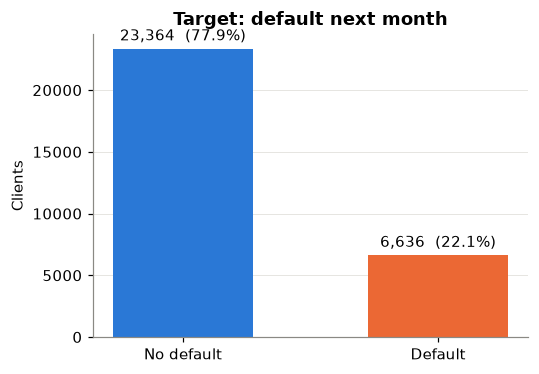

In [7]:
fig, ax = plt.subplots(figsize=(5, 3.5))
bars = ax.bar([TARGET_LABELS[i] for i in counts.index], counts.values,
              color=[TARGET_COLORS[i] for i in counts.index], width=0.55)
ax.bar_label(bars, labels=[f"{v:,}  ({v/len(df):.1%})" for v in counts.values], padding=3)
ax.set_title("Target: default next month")
ax.set_ylabel("Clients")
ax.grid(axis="x", visible=False)
plt.tight_layout(); plt.show()

## Categorical features

### Value counts and default rate by category

In [8]:
tables = []
for col in CAT_COLS:
    t = df.groupby(col)[TARGET].agg(count="size", default_rate="mean")
    t["share"] = t["count"] / len(df)
    t.index = pd.MultiIndex.from_product([[col], t.index], names=["feature", "code"])
    tables.append(t[["count", "share", "default_rate"]])
pd.concat(tables)

count  share  default_rate
feature   code                            
SEX       1     11888  0.396         0.242
          2     18112  0.604         0.208
EDUCATION 0        14  0.000         0.000
          1     10585  0.353         0.192
          2     14030  0.468         0.237
          3      4917  0.164         0.252
          4       123  0.004         0.057
          5       280  0.009         0.064
          6        51  0.002         0.157
MARRIAGE  0        54  0.002         0.093
          1     13659  0.455         0.235
          2     15964  0.532         0.209
          3       323  0.011         0.260

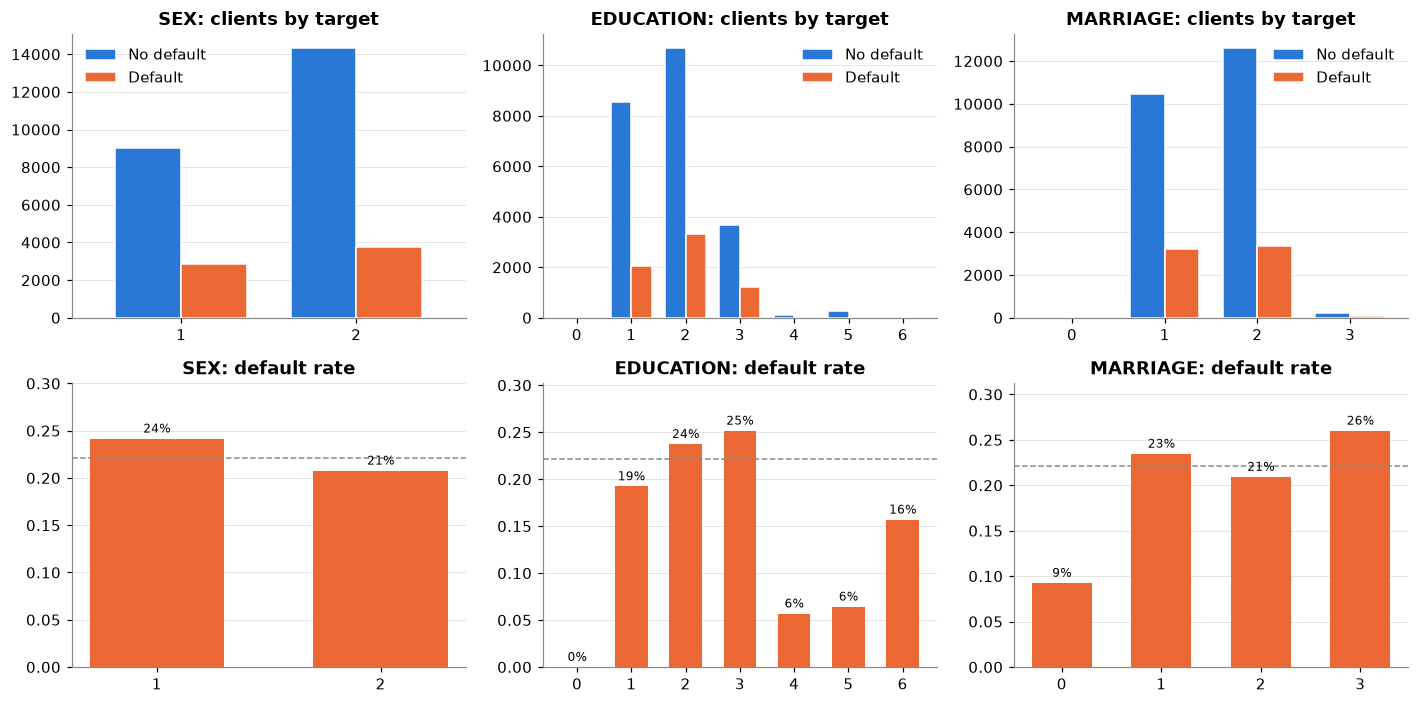

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(13, 6.5))
for j, col in enumerate(CAT_COLS):
    ct = pd.crosstab(df[col], df[TARGET])
    ct.plot.bar(ax=axes[0, j], color=[BLUE, ORANGE], width=0.75, edgecolor="white", linewidth=1)
    axes[0, j].set_title(f"{col}: clients by target")
    axes[0, j].set_xlabel(""); axes[0, j].tick_params(axis="x", rotation=0)
    axes[0, j].legend([TARGET_LABELS[0], TARGET_LABELS[1]])
    axes[0, j].grid(axis="x", visible=False)

    rate = df.groupby(col)[TARGET].mean()
    b = axes[1, j].bar(rate.index.astype(str), rate.values, color=ORANGE, width=0.6)
    axes[1, j].bar_label(b, labels=[f"{v:.0%}" for v in rate.values], padding=2, fontsize=8)
    axes[1, j].axhline(df[TARGET].mean(), color=GRAY, ls="--", lw=1)
    axes[1, j].set_title(f"{col}: default rate")
    axes[1, j].set_ylim(0, max(rate.max() * 1.2, 0.3))
    axes[1, j].grid(axis="x", visible=False)
plt.tight_layout(); plt.show()

## Numerical features: LIMIT_BAL and AGE

In [10]:
df.groupby(TARGET)[["LIMIT_BAL", "AGE"]].describe().T.rename(columns=TARGET_LABELS)

DEFAULT            No default     Default
LIMIT_BAL count    23,364.000   6,636.000
          mean    178,099.726 130,109.656
          std     131,628.360 115,378.541
          min      10,000.000  10,000.000
          25%      70,000.000  50,000.000
          50%     150,000.000  90,000.000
          75%     250,000.000 200,000.000
          max   1,000,000.000 740,000.000
AGE       count    23,364.000   6,636.000
          mean         35.417      35.726
          std           9.077       9.693
          min          21.000      21.000
          25%          28.000      28.000
          50%          34.000      34.000
          75%          41.000      42.000
          max          79.000      75.000

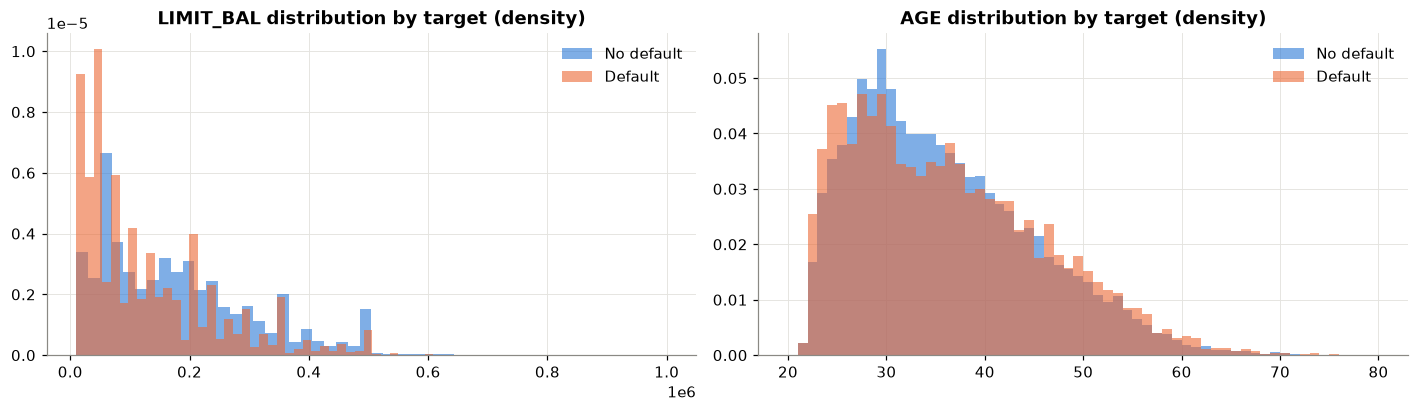

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, col, bins in [(axes[0], "LIMIT_BAL", 50), (axes[1], "AGE", np.arange(20, 81, 1))]:
    for t in [0, 1]:
        ax.hist(df.loc[df[TARGET] == t, col], bins=bins, alpha=0.6, density=True,
                color=TARGET_COLORS[t], label=TARGET_LABELS[t])
    ax.set_title(f"{col} distribution by target (density)")
    ax.legend()
plt.tight_layout(); plt.show()

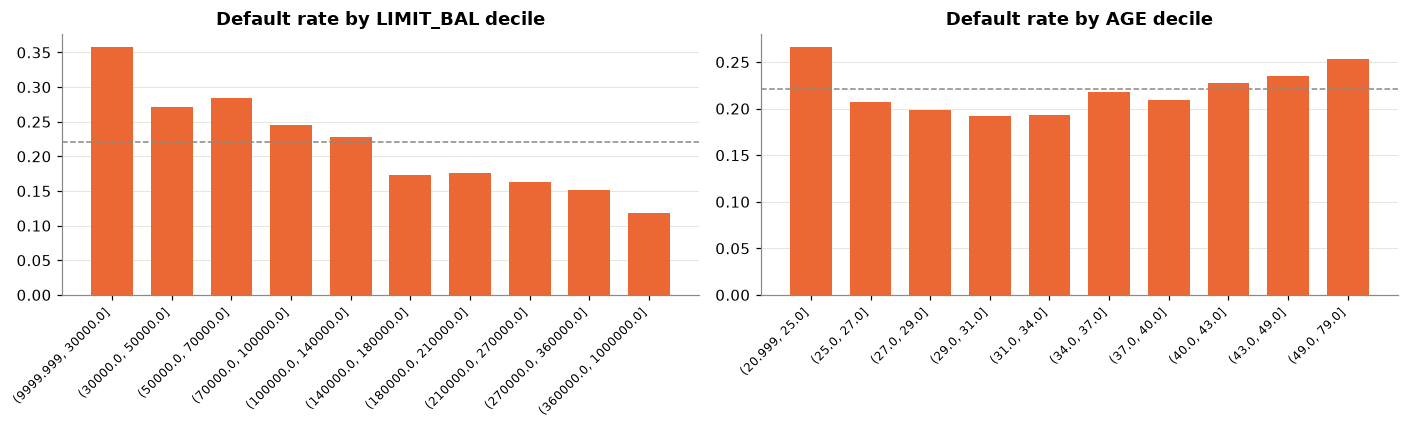

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, col, q in [(axes[0], "LIMIT_BAL", 10), (axes[1], "AGE", 10)]:
    binned = pd.qcut(df[col], q=q, duplicates="drop")
    rate = df.groupby(binned, observed=True)[TARGET].agg(["mean", "size"])
    ax.bar(range(len(rate)), rate["mean"], color=ORANGE, width=0.7)
    ax.set_xticks(range(len(rate)), [str(i) for i in rate.index], rotation=45, ha="right", fontsize=8)
    ax.axhline(df[TARGET].mean(), color=GRAY, ls="--", lw=1)
    ax.set_title(f"Default rate by {col} decile")
    ax.grid(axis="x", visible=False)
plt.tight_layout(); plt.show()

## Repayment status (PAY_1 … PAY_6)

### Value counts per month

In [13]:
pay_counts = pd.DataFrame({c: df[c].value_counts() for c in PAY_COLS}).fillna(0).astype(int).sort_index()
pay_counts.columns = [f"{c} ({m})" for c, m in zip(PAY_COLS, MONTHS)]
pay_counts

,PAY_1 (Sep),PAY_2 (Aug),PAY_3 (Jul),PAY_4 (Jun),PAY_5 (May),PAY_6 (Apr)
-2,2759,3782,4085,4348,4546,4895
-1,5686,6050,5938,5687,5539,5740
0,14737,15730,15764,16455,16947,16286
1,3688,28,4,2,0,0
2,2667,3927,3819,3159,2626,2766
3,322,326,240,180,178,184
4,76,99,76,69,84,49
5,26,25,21,35,17,13
6,11,12,23,5,4,19
7,9,20,27,58,58,46


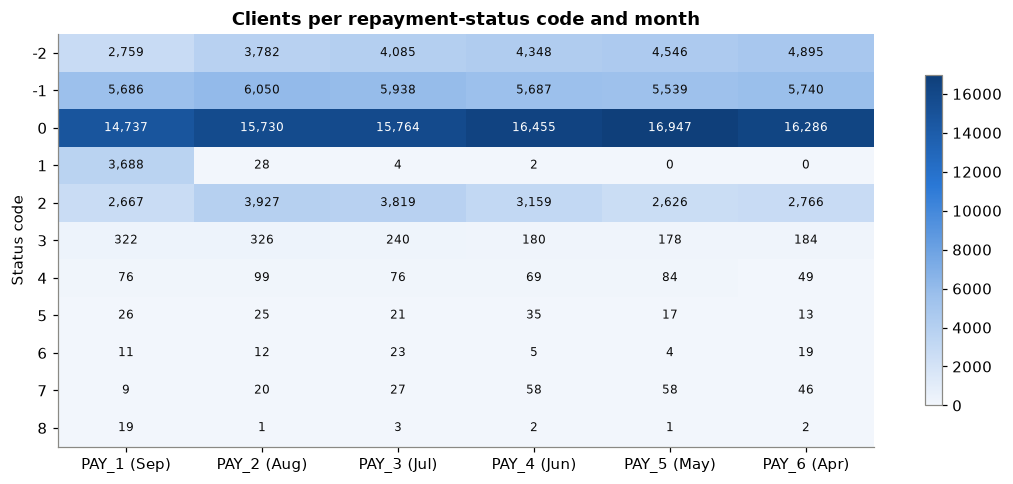

In [14]:
fig, ax = plt.subplots(figsize=(10, 4.5))
im = ax.imshow(pay_counts.values, cmap=SEQ, aspect="auto")
ax.set_xticks(range(pay_counts.shape[1]), pay_counts.columns)
ax.set_yticks(range(pay_counts.shape[0]), pay_counts.index)
ax.set_ylabel("Status code")
for i in range(pay_counts.shape[0]):
    for j in range(pay_counts.shape[1]):
        v = pay_counts.values[i, j]
        ax.text(j, i, f"{v:,}", ha="center", va="center", fontsize=8,
                color="white" if v > pay_counts.values.max() * 0.5 else "#0b0b0b")
ax.set_title("Clients per repayment-status code and month")
ax.grid(False)
fig.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout(); plt.show()

### Default rate by status code and month

In [15]:
pay_rate = pd.DataFrame({c: df.groupby(c)[TARGET].mean() for c in PAY_COLS}).sort_index()
pay_rate.columns = pay_counts.columns
pay_rate

,PAY_1 (Sep),PAY_2 (Aug),PAY_3 (Jul),PAY_4 (Jun),PAY_5 (May),PAY_6 (Apr)
-2,0.132,0.183,0.185,0.193,0.197,0.200
-1,0.168,0.160,0.156,0.159,0.162,0.170
0,0.128,0.159,0.175,0.183,0.189,0.188
1,0.339,0.179,0.250,0.500,NaN,NaN
2,0.691,0.556,0.516,0.523,0.542,0.507
3,0.758,0.617,0.575,0.611,0.635,0.641
4,0.684,0.505,0.579,0.667,0.607,0.633
5,0.500,0.600,0.571,0.514,0.588,0.538
6,0.545,0.750,0.609,0.400,0.750,0.737
7,0.778,0.600,0.815,0.828,0.828,0.826


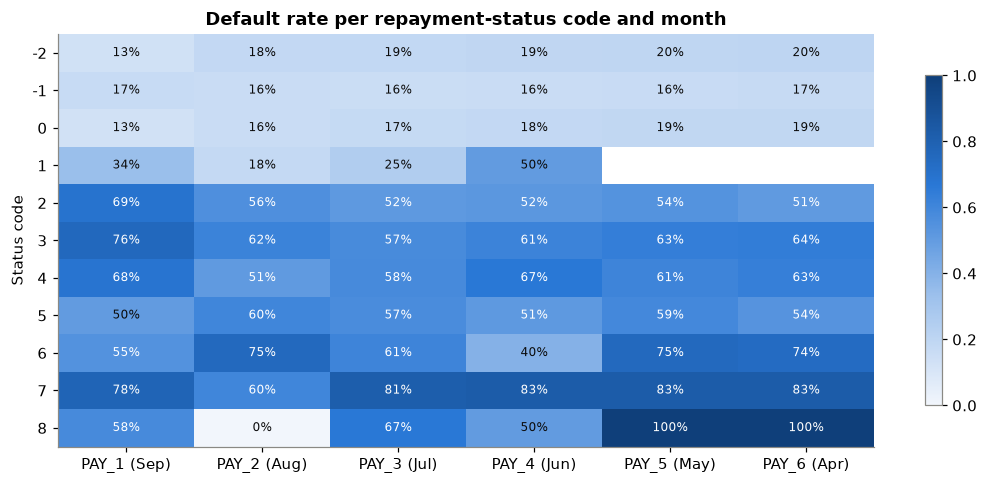

In [16]:
fig, ax = plt.subplots(figsize=(10, 4.5))
im = ax.imshow(pay_rate.values, cmap=SEQ, aspect="auto", vmin=0, vmax=1)
ax.set_xticks(range(pay_rate.shape[1]), pay_rate.columns)
ax.set_yticks(range(pay_rate.shape[0]), pay_rate.index)
ax.set_ylabel("Status code")
for i in range(pay_rate.shape[0]):
    for j in range(pay_rate.shape[1]):
        v = pay_rate.values[i, j]
        if not np.isnan(v):
            ax.text(j, i, f"{v:.0%}", ha="center", va="center", fontsize=8,
                    color="white" if v > 0.5 else "#0b0b0b")
ax.set_title("Default rate per repayment-status code and month")
ax.grid(False)
fig.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout(); plt.show()

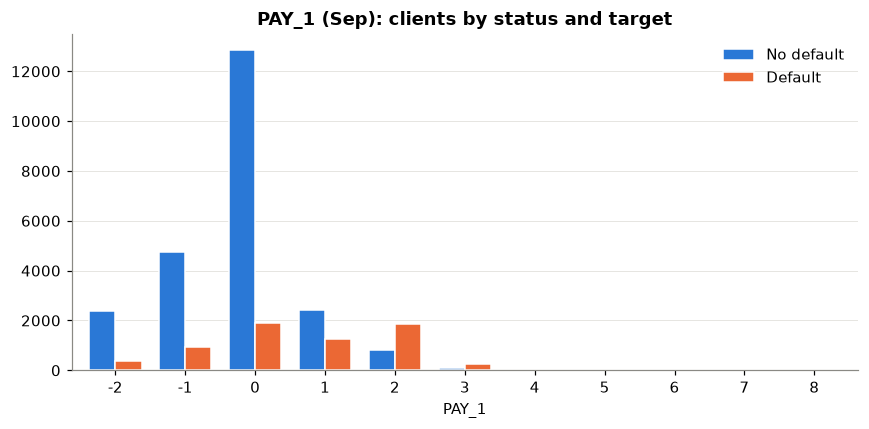

In [17]:
fig, ax = plt.subplots(figsize=(8, 4))
ct = pd.crosstab(df["PAY_1"], df[TARGET])
ct.plot.bar(ax=ax, color=[BLUE, ORANGE], width=0.75, edgecolor="white", linewidth=1)
ax.set_title("PAY_1 (Sep): clients by status and target")
ax.legend([TARGET_LABELS[0], TARGET_LABELS[1]])
ax.tick_params(axis="x", rotation=0); ax.grid(axis="x", visible=False)
plt.tight_layout(); plt.show()

## Bill amounts (BILL_AMT1 … BILL_AMT6)

In [18]:
df[BILL_COLS].describe().T

,count,mean,std,min,25%,50%,75%,max
BILL_AMT1,"30,000.000","51,223.331","73,635.861","-165,580.000","3,558.750","22,381.500","67,091.000","964,511.000"
BILL_AMT2,"30,000.000","49,179.075","71,173.769","-69,777.000","2,984.750","21,200.000","64,006.250","983,931.000"
BILL_AMT3,"30,000.000","47,013.155","69,349.387","-157,264.000","2,666.250","20,088.500","60,164.750","1,664,089.000"
BILL_AMT4,"30,000.000","43,262.949","64,332.856","-170,000.000","2,326.750","19,052.000","54,506.000","891,586.000"
BILL_AMT5,"30,000.000","40,311.401","60,797.156","-81,334.000","1,763.000","18,104.500","50,190.500","927,171.000"
BILL_AMT6,"30,000.000","38,871.760","59,554.108","-339,603.000","1,256.000","17,071.000","49,198.250","961,664.000"


In [19]:
pd.DataFrame({
    "n_negative": (df[BILL_COLS] < 0).sum(),
    "n_zero": (df[BILL_COLS] == 0).sum(),
    "n_above_limit": df[BILL_COLS].gt(df["LIMIT_BAL"], axis=0).sum(),
}).assign(month=MONTHS)

,n_negative,n_zero,n_above_limit,month
BILL_AMT1,590,2008,2115,Sep
BILL_AMT2,669,2506,1940,Aug
BILL_AMT3,655,2870,1583,Jul
BILL_AMT4,675,3195,1018,Jun
BILL_AMT5,655,3506,820,May
BILL_AMT6,688,4020,798,Apr


In [20]:
pd.Series({
    "clients with any negative bill": int((df[BILL_COLS] < 0).any(axis=1).sum()),
    "clients with all bills zero": int((df[BILL_COLS] == 0).all(axis=1).sum()),
    "clients with any bill above limit": int(df[BILL_COLS].gt(df["LIMIT_BAL"], axis=0).any(axis=1).sum()),
}, name="count").to_frame()

,count
clients with any negative bill,1930
clients with all bills zero,866
clients with any bill above limit,3931


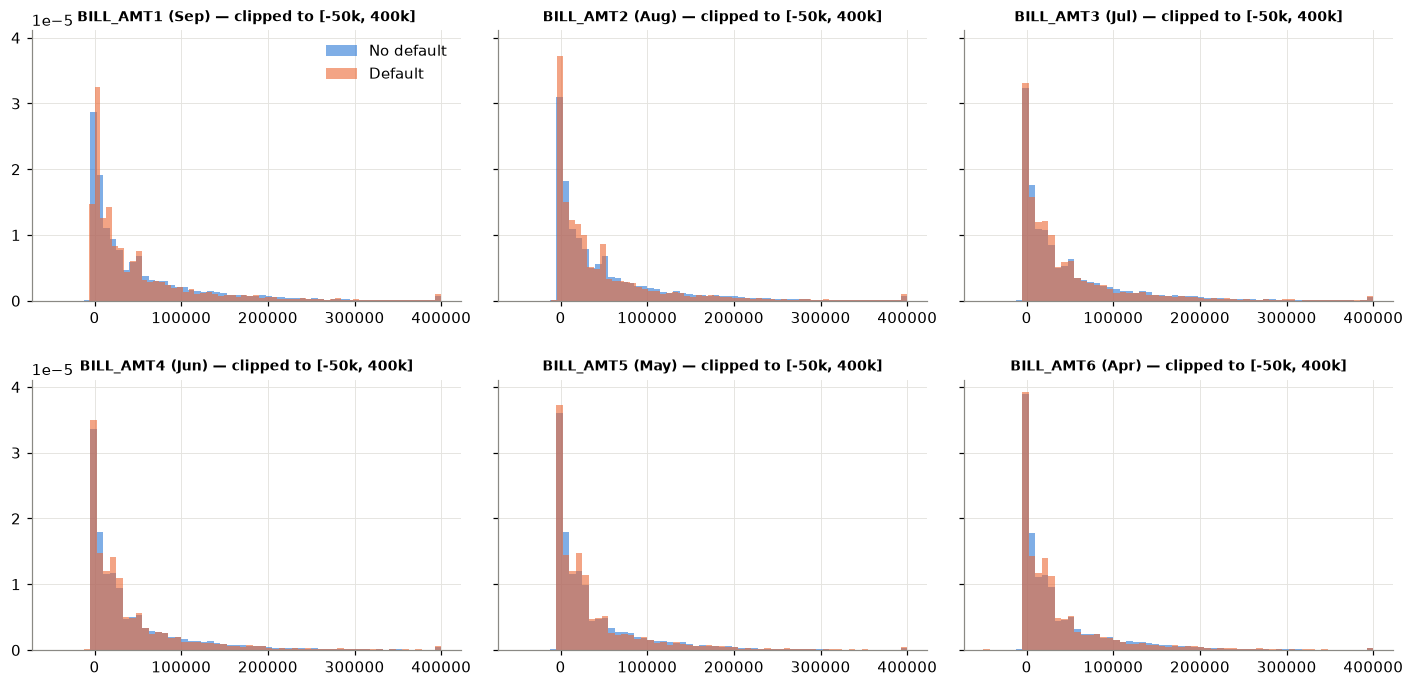

In [21]:
fig, axes = plt.subplots(2, 3, figsize=(13, 6.5), sharey=True)
for ax, col, m in zip(axes.ravel(), BILL_COLS, MONTHS):
    for t in [0, 1]:
        ax.hist(df.loc[df[TARGET] == t, col].clip(-50_000, 400_000), bins=60, alpha=0.6,
                density=True, color=TARGET_COLORS[t], label=TARGET_LABELS[t])
    ax.set_title(f"{col} ({m}) — clipped to [-50k, 400k]", fontsize=9)
axes[0, 0].legend()
plt.tight_layout(); plt.show()

## Payment amounts (PAY_AMT1 … PAY_AMT6)

In [22]:
df[PAYAMT_COLS].describe().T

,count,mean,std,min,25%,50%,75%,max
PAY_AMT1,"30,000.000","5,663.581","16,563.280",0.000,"1,000.000","2,100.000","5,006.000","873,552.000"
PAY_AMT2,"30,000.000","5,921.163","23,040.870",0.000,833.000,"2,009.000","5,000.000","1,684,259.000"
PAY_AMT3,"30,000.000","5,225.681","17,606.961",0.000,390.000,"1,800.000","4,505.000","896,040.000"
PAY_AMT4,"30,000.000","4,826.077","15,666.160",0.000,296.000,"1,500.000","4,013.250","621,000.000"
PAY_AMT5,"30,000.000","4,799.388","15,278.306",0.000,252.500,"1,500.000","4,031.500","426,529.000"
PAY_AMT6,"30,000.000","5,215.503","17,777.466",0.000,117.750,"1,500.000","4,000.000","528,666.000"


In [23]:
pd.DataFrame({
    "n_zero": (df[PAYAMT_COLS] == 0).sum(),
    "share_zero": (df[PAYAMT_COLS] == 0).mean(),
}).assign(month=MONTHS)

,n_zero,share_zero,month
PAY_AMT1,5249,0.175,Sep
PAY_AMT2,5396,0.180,Aug
PAY_AMT3,5968,0.199,Jul
PAY_AMT4,6408,0.214,Jun
PAY_AMT5,6703,0.223,May
PAY_AMT6,7173,0.239,Apr


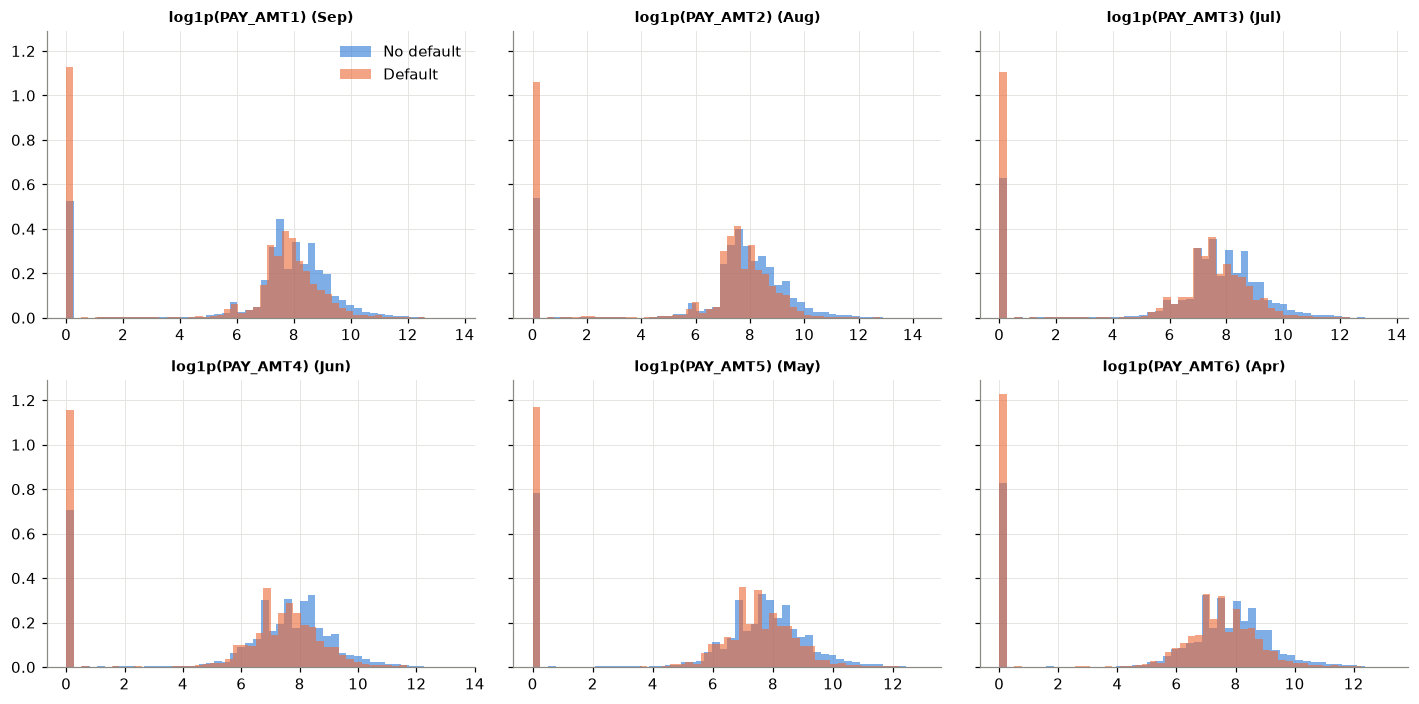

In [24]:
fig, axes = plt.subplots(2, 3, figsize=(13, 6.5), sharey=True)
for ax, col, m in zip(axes.ravel(), PAYAMT_COLS, MONTHS):
    for t in [0, 1]:
        ax.hist(np.log1p(df.loc[df[TARGET] == t, col]), bins=50, alpha=0.6,
                density=True, color=TARGET_COLORS[t], label=TARGET_LABELS[t])
    ax.set_title(f"log1p({col}) ({m})", fontsize=9)
axes[0, 0].legend()
plt.tight_layout(); plt.show()

## Monthly trajectories by target

In [25]:
traj = {
    "Mean bill amount": df.groupby(TARGET)[BILL_COLS].mean().T,
    "Mean payment amount": df.groupby(TARGET)[PAYAMT_COLS].mean().T,
    "Mean repayment status": df.groupby(TARGET)[PAY_COLS].mean().T,
}
for k, v in traj.items():
    v.index = MONTHS
pd.concat(traj, axis=1).rename(columns=TARGET_LABELS, level=1).iloc[::-1]

Mean bill amount            Mean payment amount            \
DEFAULT       No default    Default          No default   Default   
Apr           39,042.269 38,271.436           5,719.372 3,441.482   
May           40,530.445 39,540.190           5,248.220 3,219.140   
Jun           43,611.165 42,036.951           5,300.529 3,155.627   
Jul           47,533.366 45,181.599           5,753.497 3,367.352   
Aug           49,717.436 47,283.618           6,640.465 3,388.650   
Sep           51,994.227 48,509.162           6,307.337 3,397.044   

        Mean repayment status          
DEFAULT            No default Default  
Apr                    -0.406   0.112  
May                    -0.389   0.168  
Jun                    -0.356   0.255  
Jul                    -0.316   0.362  
Aug                    -0.302   0.458  
Sep                    -0.211   0.668

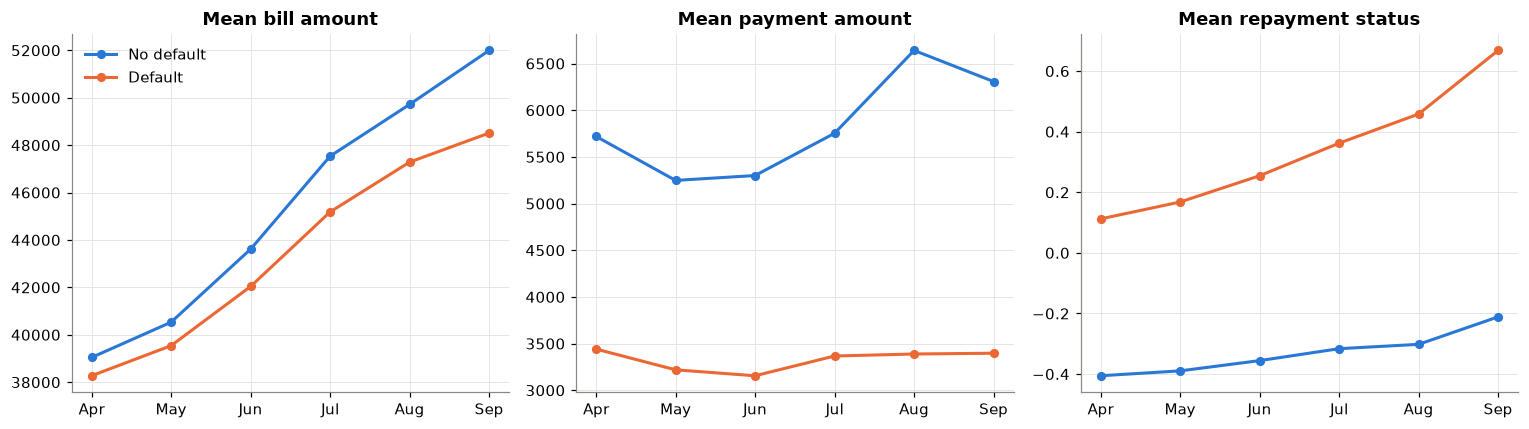

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (title, t) in zip(axes, traj.items()):
    t = t.iloc[::-1]  # chronological Apr -> Sep
    for c in [0, 1]:
        ax.plot(t.index, t[c], color=TARGET_COLORS[c], lw=2, marker="o", ms=5, label=TARGET_LABELS[c])
    ax.set_title(title)
axes[0].legend()
plt.tight_layout(); plt.show()

## Correlations

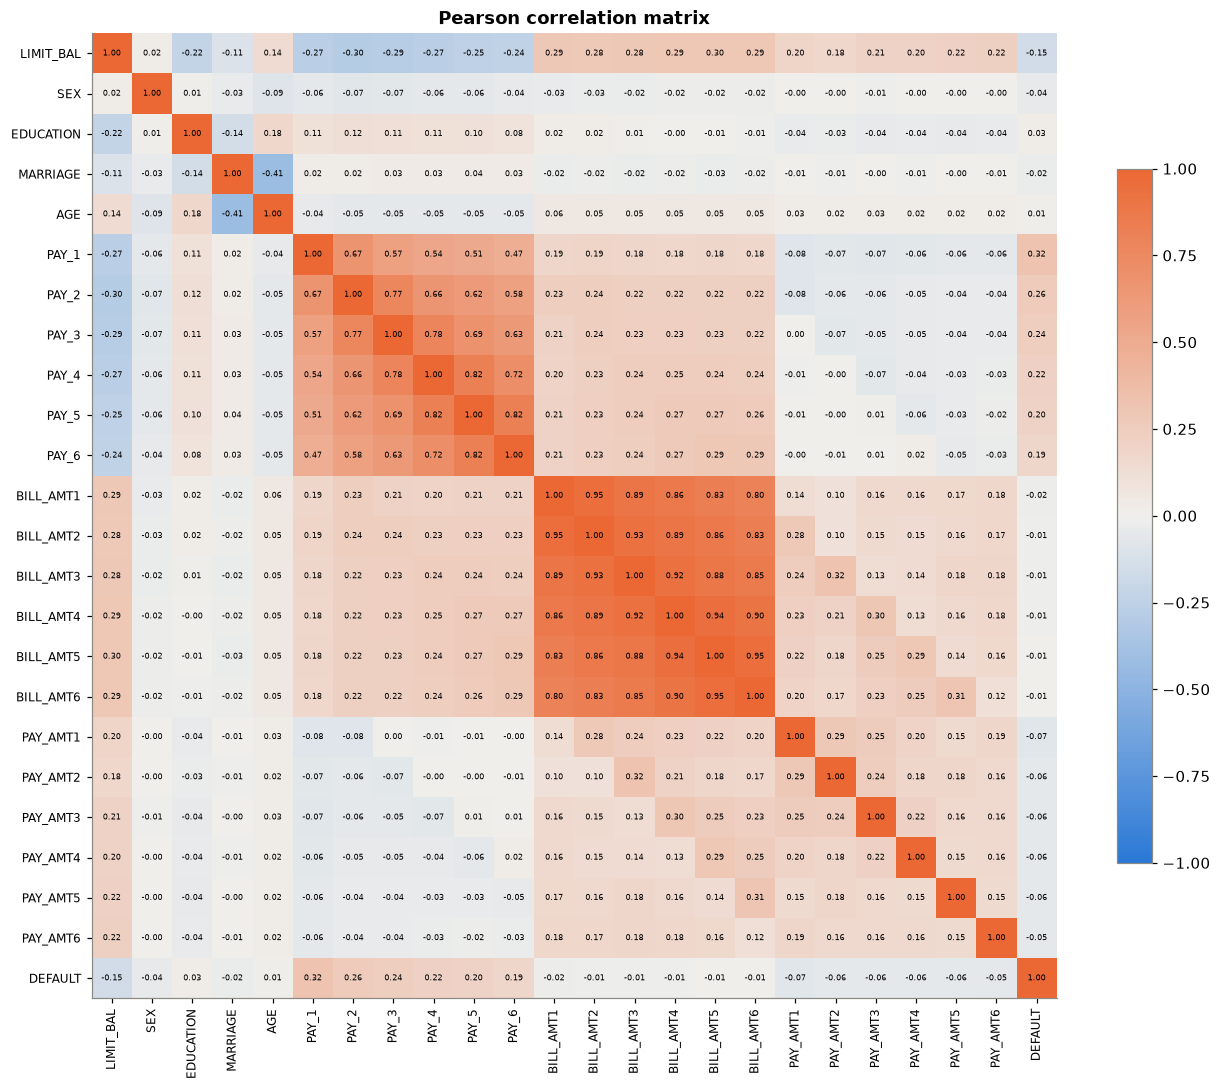

In [27]:
corr = df.drop(columns="ID").corr()
fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(corr.values, cmap=DIV, vmin=-1, vmax=1)
ax.set_xticks(range(len(corr)), corr.columns, rotation=90, fontsize=8)
ax.set_yticks(range(len(corr)), corr.columns, fontsize=8)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f"{corr.values[i, j]:.2f}", ha="center", va="center", fontsize=5.5)
ax.set_title("Pearson correlation matrix")
ax.grid(False)
fig.colorbar(im, ax=ax, shrink=0.7)
plt.tight_layout(); plt.show()

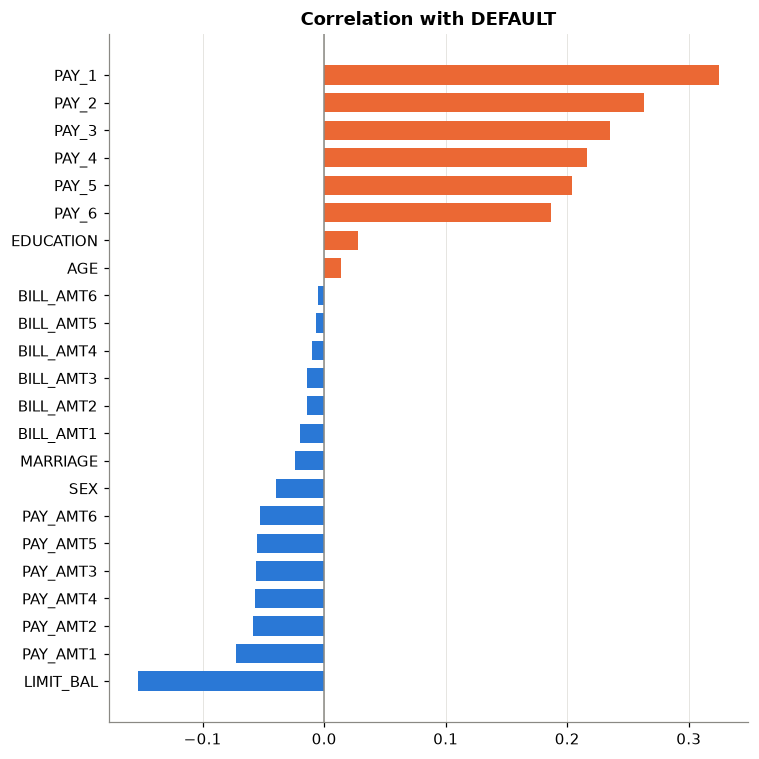

,corr_with_target
PAY_1,0.325
PAY_2,0.264
PAY_3,0.235
PAY_4,0.217
PAY_5,0.204
PAY_6,0.187
LIMIT_BAL,-0.154
PAY_AMT1,-0.073
PAY_AMT2,-0.059
PAY_AMT4,-0.057


In [28]:
target_corr = corr[TARGET].drop(TARGET).sort_values()
fig, ax = plt.subplots(figsize=(7, 7))
ax.barh(target_corr.index, target_corr.values,
        color=[ORANGE if v > 0 else BLUE for v in target_corr.values], height=0.7)
ax.axvline(0, color=GRAY, lw=1)
ax.set_title(f"Correlation with {TARGET}")
ax.grid(axis="y", visible=False)
plt.tight_layout(); plt.show()
target_corr.sort_values(key=abs, ascending=False).to_frame("corr_with_target")